# ***02. Feature Engineering*** 

`EDA(Exploratory Data Analysis) is already finised!`

---
## ***1. Loading Data***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
!pip install category_encoders --quiet
!pip install catboost --quiet

In [2]:
df = pd.read_csv("../data/Car Sell Dataset.csv")
df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Year,Kilometers,Owner,State,Accidental,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,2017,164654,1st,Rajasthan,No,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,2018,41351,1st,Maharashtra,No,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,2002,119090,3rd+,Tamil Nadu,No,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,2013,19979,1st,Andhra Pradesh,No,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,2011,130591,3rd+,Bihar,No,401182


---
## ***2. Observations***

### ***For Anomalies***
1. If Accidental = Yes then Price should be low
2. If Car is Luxury then Price should be high
3. If No. of Owners is high then Price should be low
4. If Kilometers is high then Price should be low
5. If a Car is Automatic then Price should be High

---
## ***3. Creating Features***

In [3]:
new_df = df.copy()

In [4]:
from datetime import datetime

current_year = datetime.now().year

new_df["Car_Age"] = current_year - new_df["Year"]

new_df = new_df.drop(columns=["Year"])
new_df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Price,Car_Age
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,164654,1st,Rajasthan,No,547253,9
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,41351,1st,Maharashtra,No,512050,8
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,119090,3rd+,Tamil Nadu,No,678923,24
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,19979,1st,Andhra Pradesh,No,522500,13
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,130591,3rd+,Bihar,No,401182,15


In [5]:
new_df.columns

Index(['Brand', 'Model Name', 'Model Variant', 'Car Type', 'Transmission',
       'Fuel Type', 'Kilometers', 'Owner', 'State', 'Accidental', 'Price',
       'Car_Age'],
      dtype='object')

In [6]:
price = new_df["Price"]
price

new_df = new_df.drop(columns=["Price"])
new_df["Price"] = price
new_df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,164654,1st,Rajasthan,No,9,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,41351,1st,Maharashtra,No,8,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,119090,3rd+,Tamil Nadu,No,24,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,19979,1st,Andhra Pradesh,No,13,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,130591,3rd+,Bihar,No,15,401182


---
## ***3. Features Transformations***

In [7]:
new_df["Owner"].value_counts()

Owner
1st     75429
2nd     56492
3rd+     8983
Name: count, dtype: int64

In [8]:
new_df["Owner"] = new_df["Owner"].map(
    {"1st":1, "2nd":2, "3rd+":3}
)
new_df["Accidental"] = new_df["Accidental"].map(
    {"No": 0, "Yes": 1}
)
new_df["Transmission"] = new_df["Transmission"].map(
    {"Manual": 0, "Automatic": 1}
)

new_df.sample()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,Price
34858,Jaguar,XE,Portfolio,Sedan,0,Petrol,25517,1,Bihar,1,6,498691


In [9]:
X = new_df.drop(columns=["Price"])
y = new_df["Price"]

In [10]:
X.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age
0,Mahindra,TUV300,AX5,SUV,0,CNG,164654,1,Rajasthan,0,9
1,Skoda,Rapid,Style,Sedan,0,Petrol,41351,1,Maharashtra,0,8
2,Maruti Suzuki,Alto,Z,Hatchback,0,Diesel,119090,3,Tamil Nadu,0,24
3,Hyundai,Grand i10,Magna,Hatchback,0,Diesel,19979,1,Andhra Pradesh,0,13
4,Mahindra,XUV500,W8,SUV,0,Petrol,130591,3,Bihar,0,15


In [11]:
new_df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,Price
0,Mahindra,TUV300,AX5,SUV,0,CNG,164654,1,Rajasthan,0,9,547253
1,Skoda,Rapid,Style,Sedan,0,Petrol,41351,1,Maharashtra,0,8,512050
2,Maruti Suzuki,Alto,Z,Hatchback,0,Diesel,119090,3,Tamil Nadu,0,24,678923
3,Hyundai,Grand i10,Magna,Hatchback,0,Diesel,19979,1,Andhra Pradesh,0,13,522500
4,Mahindra,XUV500,W8,SUV,0,Petrol,130591,3,Bihar,0,15,401182


In [12]:
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        (
            "target",
            TargetEncoder(),
            ["Brand", "Model Name", "Model Variant", "State"]
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            ["Fuel Type","Car Type"]
        )
    ],
    remainder="passthrough"
)

In [13]:
new_df["Fuel Type"].value_counts()

Fuel Type
Petrol      79187
Diesel      42038
CNG         14054
Electric     2853
Hybrid       2772
Name: count, dtype: int64

In [14]:
new_df["Car Type"].value_counts()

Car Type
Hatchback    55890
Sedan        36897
SUV          35057
MPV           9702
Luxury        3358
Name: count, dtype: int64

In [15]:
new_df["Model Variant"].value_counts()

Model Variant
V            14975
ZX           14896
Base         14199
L            10824
Z            10692
             ...  
R-Dynamic      221
Portfolio      217
LTZ            196
LS             190
LT             169
Name: count, Length: 82, dtype: int64

In [16]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140904 entries, 0 to 140903
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Brand          140904 non-null  object
 1   Model Name     140904 non-null  object
 2   Model Variant  140904 non-null  object
 3   Car Type       140904 non-null  object
 4   Transmission   140904 non-null  int64 
 5   Fuel Type      140904 non-null  object
 6   Kilometers     140904 non-null  int64 
 7   Owner          140904 non-null  int64 
 8   State          140904 non-null  object
 9   Accidental     140904 non-null  int64 
 10  Car_Age        140904 non-null  int64 
 11  Price          140904 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 12.9+ MB


In [17]:
new_df["State"].nunique()

27

In [18]:
new_df["Brand"].nunique()

18

In [19]:
new_df["Model Name"].nunique()

84

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_train_df["Prices"] = y_train.values
X_test_processed = preprocessor.transform(X_test)
X_train_df.head()

,target__Brand,target__Model Name,target__Model Variant,target__State,onehot__Fuel Type_CNG,onehot__Fuel Type_Diesel,onehot__Fuel Type_Electric,onehot__Fuel Type_Hybrid,onehot__Fuel Type_Petrol,onehot__Car Type_Hatchback,onehot__Car Type_Luxury,onehot__Car Type_MPV,onehot__Car Type_SUV,onehot__Car Type_Sedan,remainder__Transmission,remainder__Kilometers,remainder__Owner,remainder__Accidental,remainder__Car_Age,Prices
0,746559.975677,624623.194860,733484.458151,786930.123503,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,119069.0,1.0,0.0,6.0,1320000
1,764426.487317,864829.590944,733484.458151,670949.572193,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22268.0,1.0,0.0,4.0,1396500
2,746559.975677,749463.083454,704796.919178,790990.695046,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,145608.0,1.0,0.0,9.0,554400
3,689419.054739,725301.899630,721717.007884,673301.610401,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,112145.0,2.0,0.0,13.0,432441
4,746559.975677,627695.876446,786981.316272,790990.695046,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,129376.0,2.0,0.0,15.0,431244


In [22]:
X_train_df.to_csv("../data/processed_train_data.csv")

---
## ***4. Baseline Modeling***

### ***4.1 Xgboost***

In [23]:
!pip install xgboost

In [24]:
import xgboost as xgb

In [25]:
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [26]:
base_xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor())
])

xgb_model = base_xgb_model.named_steps["regressor"]
base_xgb_model.fit(X_train, y_train)
y_base_xgb_pred = base_xgb_model.predict(X_test)

print(r2_score(y_test, y_base_xgb_pred))

0.315363347530365


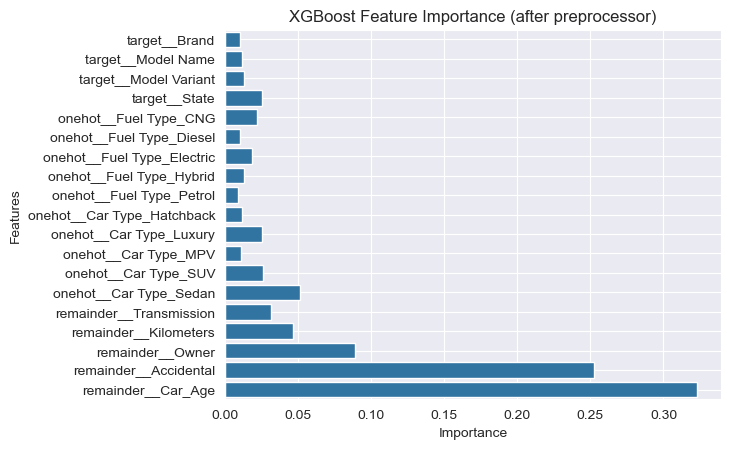

In [27]:
xgb_importances = xgb_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

sns.set_style("dark")
sns.barplot(x=xgb_importances, y=feature_names)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance (after preprocessor)")
plt.grid(True)
plt.savefig("../plots/xgboost_feature_importance.png")
plt.show()

### ***4.2 Catboost***

In [28]:
base_catboost_model = Pipeline([
     ("preprocessor", preprocessor),
     ("regressor", CatBoostRegressor())
])

catboost_model = base_catboost_model.named_steps["regressor"]
base_catboost_model.fit(X_train, y_train)
y_base_catboost_pred = base_catboost_model.predict(X_test)

print(r2_score(y_test, y_base_catboost_pred))

Learning rate set to 0.086377
0:	learn: 432640.2348955	total: 146ms	remaining: 2m 25s
1:	learn: 423092.8349856	total: 161ms	remaining: 1m 20s
2:	learn: 414629.8545103	total: 177ms	remaining: 58.8s
3:	learn: 407409.4344207	total: 191ms	remaining: 47.7s
4:	learn: 401079.9044352	total: 207ms	remaining: 41.1s
5:	learn: 395753.3085442	total: 222ms	remaining: 36.8s
6:	learn: 391257.2196826	total: 236ms	remaining: 33.5s
7:	learn: 387489.7931472	total: 250ms	remaining: 31s
8:	learn: 384250.9198333	total: 262ms	remaining: 28.9s
9:	learn: 381504.9102741	total: 275ms	remaining: 27.2s
10:	learn: 379147.3337964	total: 288ms	remaining: 25.9s
11:	learn: 377231.3839771	total: 302ms	remaining: 24.8s
12:	learn: 375557.9865189	total: 316ms	remaining: 24s
13:	learn: 374048.2334114	total: 330ms	remaining: 23.3s
14:	learn: 372806.5332564	total: 344ms	remaining: 22.6s
15:	learn: 371688.3886076	total: 356ms	remaining: 21.9s
16:	learn: 370764.9774559	total: 370ms	remaining: 21.4s
17:	learn: 369949.0984492	tota

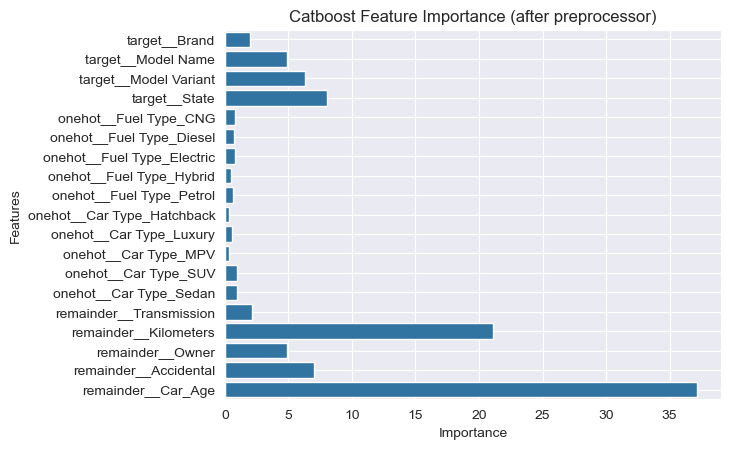

In [29]:
catboost_importances = catboost_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

sns.set_style("dark")
sns.barplot(x=catboost_importances, y=feature_names)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Catboost Feature Importance (after preprocessor)")
plt.grid(True)
plt.savefig("../plots/catboost_feature_importance.png")
plt.show()

## ***5. Scaling Features***

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

In [31]:
X_train_scaled.shape

(112723, 19)

In [32]:
X_test_scaled.shape

(28181, 19)

In [33]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_names
)
X_train_scaled["Price"] = y_train.values

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)
X_test_scaled["Price"] = y_test.values

In [34]:
X_train_scaled.head()

,target__Brand,target__Model Name,target__Model Variant,target__State,onehot__Fuel Type_CNG,onehot__Fuel Type_Diesel,onehot__Fuel Type_Electric,onehot__Fuel Type_Hybrid,onehot__Fuel Type_Petrol,onehot__Car Type_Hatchback,onehot__Car Type_Luxury,onehot__Car Type_MPV,onehot__Car Type_SUV,onehot__Car Type_Sedan,remainder__Transmission,remainder__Kilometers,remainder__Owner,remainder__Accidental,remainder__Car_Age,Price
0,-0.227056,-0.989260,-0.415871,0.517826,-0.332852,1.534845,-0.144515,-0.140529,-1.133757,1.231772,-0.156118,-0.271865,-0.575537,-0.594758,-0.418703,0.485928,-0.860915,-0.294211,-0.594113,1320000
1,0.034291,0.739447,-0.415871,-1.899188,-0.332852,1.534845,-0.144515,-0.140529,-1.133757,-0.811839,-0.156118,-0.271865,1.737507,-0.594758,-0.418703,-1.484115,-0.860915,-0.294211,-0.985815,1396500
2,-0.227056,-0.090817,-0.833047,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,-0.156118,3.678302,-0.575537,-0.594758,-0.418703,1.026036,-0.860915,-0.294211,-0.006561,554400
3,-1.062900,-0.264700,-0.586994,-1.850171,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,-0.156118,-0.271865,-0.575537,1.681356,2.388329,0.345015,0.768996,-0.294211,0.776843,432441
4,-0.227056,-0.967146,0.362084,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,1.231772,-0.156118,-0.271865,-0.575537,-0.594758,-0.418703,0.695691,0.768996,-0.294211,1.168545,431244


In [35]:
X_test_scaled.head()

,target__Brand,target__Model Name,target__Model Variant,target__State,onehot__Fuel Type_CNG,onehot__Fuel Type_Diesel,onehot__Fuel Type_Electric,onehot__Fuel Type_Hybrid,onehot__Fuel Type_Petrol,onehot__Car Type_Hatchback,onehot__Car Type_Luxury,onehot__Car Type_MPV,onehot__Car Type_SUV,onehot__Car Type_Sedan,remainder__Transmission,remainder__Kilometers,remainder__Owner,remainder__Accidental,remainder__Car_Age,Price
0,-0.227056,-0.989260,-0.833047,-1.893143,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,1.231772,-0.156118,-0.271865,-0.575537,-0.594758,-0.418703,1.525115,-0.860915,-0.294211,-0.789964,889200
1,-1.062900,-0.860929,-1.297926,-1.893143,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,-0.156118,-0.271865,-0.575537,1.681356,-0.418703,-0.377748,0.768996,-0.294211,0.972694,114007
2,-0.227056,-0.989260,-0.489832,0.610638,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,1.231772,-0.156118,-0.271865,-0.575537,-0.594758,-0.418703,-1.632376,0.768996,-0.294211,1.560247,745360
3,-0.903191,-0.854251,-0.954798,0.498822,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,-0.156118,-0.271865,1.737507,-0.594758,-0.418703,-0.831484,0.768996,-0.294211,1.560247,389077
4,-1.062900,0.845617,-0.574081,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,-0.156118,-0.271865,1.737507,-0.594758,2.388329,0.138874,0.768996,-0.294211,-0.398262,645668


In [36]:
X_train_scaled.to_csv("../data/scaled_train_data.csv")
X_test_scaled.to_csv("../data/scaled_test_data.csv")

---
## ***6. Conclusion***

Feature engineering for used car fraud detection revealed a critical data leakage trap: derived temporal features like Car_Age and Km_per_year pushed tree models to R² = 0.99 by allowing them to trivially reconstruct price from year alone. After removing redundant derivations and replacing them with semantically meaningful signals — brand-state target encodings, ownership sequences, and mileage-adjusted depreciation features — the model generalised to a more honest R² that reflects actual market learning rather than arithmetic shortcuts. The most valuable features across both XGBoost and CatBoost consistently proved to be `car_year`, `km`, and `state` — confirming that temporal depreciation and regional market variation are the primary price drivers in India's used car market. These engineered features now form the input foundation for the downstream anomaly detection pipeline, where the price residual from this model becomes the strongest fraud signal.